In [3]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform
colors = [
    '#1f77b4',  # Blue
    '#ff7f0e',  # Orange
    '#2ca02c',  # Green
    '#d62728',  # Red
    '#9467bd',  # Purple
    '#8c564b',  # Brown
    '#e377c2',  # Pink
    '#7f7f7f',  # Gray
    '#bcbd22',  # Yellow-green
    '#17becf'   # Cyan
]

In [2]:
tg_vec = np.linspace(40, 200, num=21)

# param = np.loadtxt('data/0815/aaa.txt', delimiter=',')
f_40 =  [-0.9070845082051546, -1.2598973169220298, -1.849313479425224, -2.116756844048582,
-2.403782531642886, -2.8511412131950387, -2.9697040751011623, -3.270950576996622,
-3.4164628913980426, -4.041826216786483, -3.7768887863243155, -4.059237374862007,
-3.845976129230374, -4.213672599770272, -4.989193208162769, -4.509901945861088,
-4.460128704615228, -4.3340550458755285, -4.507361305797105, -4.489470911585019, -4.461971925164813]
f_1600_9 =  [-0.9051693670250833, -1.2541215281965623, -1.821955392485761, -2.0542721955855776,
-2.2684515512212635, -2.5128483573769076, -2.526328680501479, -2.575381270016941,
-2.6046796908219085, -2.6112251811250555, -2.5080990043267097, -2.487977868148923,
-2.4526414064027775, -2.4486309078983597, -2.4436790542026876, -2.3816708400500906,
-2.3690808838006037, -2.3444688503377913, -2.32391502201516, -2.3029017936292075, -2.285922216733808]
f_1600_100 = [
-0.9068451680149641, -1.2591930365003756, -1.8459588935092535, -2.109101779348597 ,
-2.3863203863467346, -2.797759213935785, -2.892449670293085, -3.1151200300254196 ,
-3.209972793465119, -3.455983026111865, -3.3194505021583565, -3.3739926980659485 ,
-3.2994485051201456, -3.3611336889778727, -3.4006952186505104, -3.332468601422884 ,
-3.3156069563165134, -3.2845757594306466, -3.277372951342401, -3.2570965444052784 ,
-3.2392648048466253 ,
]
inf_40 = [10**(f_40[i]) for i in range(len(f_40))]
inf_1600_9 = [10**(f_1600_9[i]) for i in range(len(f_1600_9))]
inf_1600_100 = [10**(f_1600_100[i]) for i in range(len(f_1600_100))]

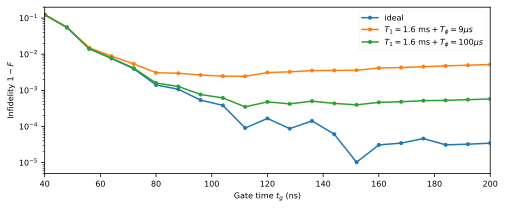

In [3]:
fig, ax = plt.subplots(figsize=(8,3))
plt.plot(tg_vec, inf_40, '.-', color=colors[0], label=r'ideal')
plt.plot(tg_vec, inf_1600_9, '.-', color=colors[1], label=r'$T_1=1.6\ {\rm ms}+T_{\phi}=9\mu s$')
plt.plot(tg_vec, inf_1600_100, '.-', color=colors[2], label=r'$T_1=1.6\ {\rm ms}+T_{\phi}=100\mu s$')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [4]:
f_dark = [
-0.7867512886745673, -0.9551963708402209, -1.1420776767573262, -1.5493438035097946 ,
-1.844010610154276, -2.3756863372014254, -2.8650409394621548, -3.2723739468972037 ,
-3.5143757812020398, -3.792153104827175, -3.7479638808557874, -3.734591322105788 ,
-3.4899611895777536, -3.5603791939172122, -4.020406620485938, -4.30131792076429 ,
-4.299283735896858, -4.718291932412348, -4.404821234286704 ,]
inf_dark = [10**(f_dark[i]) for i in range(len(f_dark))]
f_dark_correct = [
-0.5729442295730862, -0.7340924459606013, -0.9013088096394402, -1.1460086836430365 ,
-1.355531221288533, -1.452637538253877, -1.8078364038462877, -2.3802384797234093 ,
-2.4954763756068172, -3.129480716937766, -3.5249555678663325, -3.8916312978101613 ,
-3.556304412205746, -3.6021348106232898, -3.6705502487505584, -3.6652231253260728 ,
-3.678208104250878, -3.748775481544553, -3.894908359125151 ,]
inf_dark_correct = [10**(f_dark_correct[i]) for i in range(len(f_dark_correct))]

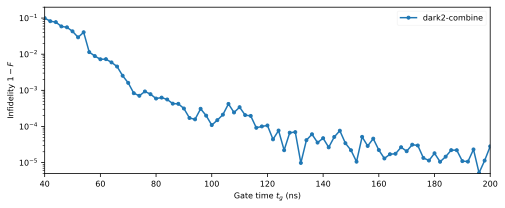

In [6]:
para_dark = pd.read_csv('data/data_cz_n1n2_20_dark.txt').to_numpy()

fig, ax = plt.subplots(figsize=(8,3))
plt.plot(para_dark[:,0], 10**para_dark[:,1], '.-', color=colors[0], label=r'dark2-combine')
# plt.plot(tg_vec[:19], inf_dark_correct, '.-', color=colors[3], label=r'$1-F_{\rm coherent}$--dark2')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [7]:
columns = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp']
params = pd.read_csv('data/data_cz_n2_20.txt').to_numpy()
param_40 = []
param_41 = []
param_42 = []
param_44 = []
param_46 = []
for i in range(20):
    param_40.append(params[8*i+0].tolist())
    param_42.append(params[8*i+2].tolist())
    param_44.append(params[8*i+4].tolist())
    param_46.append(params[8*i+6].tolist())
param_40 = np.array(param_40)
param_42 = np.array(param_42)
param_44 = np.array(param_44)
param_46 = np.array(param_46)
for i in range(80):
    param_41.append(params[2*i+1].tolist())
param_41 = np.array(param_41)


In [8]:
f_3000_50 = np.array([
-1.0573659748319053, -1.4518658769357982, -2.004866724572045, -2.286257435207804 ,
-2.54816328853917, -3.0518798136742453, -3.2055619650565492, -2.9754678665541157 ,
-3.0231722994328836, -3.1006160611266367, -3.1039869086954015, -3.147509930727078 ,
-3.1563560637026864, -3.148857367631352, -3.1257969664381777, -3.081577430169305 ,
-3.0606960365349476, -3.039547044825624, -3.016524886574164, -2.9945874307840747 ,
])
f_1600_9 = np.array([
-1.0546849247768006, -1.4436402731946916, -1.9695384548865447, -2.2074842440961207 ,
-2.386585545238544, -2.6249916436640106, -2.636708565702304, -2.5325987047667042 ,
-2.512889261972158, -2.507522743152992, -2.49332538396722, -2.484534788643627 ,
-2.4589065405330075, -2.4397635063125427, -2.4110861826277903, -2.369213893931757 ,
-2.3467199807752865, -2.326899445412735, -2.305605088261082, -2.2871739614008657 ,
])
f_1600_inf = np.array([
-1.057915120335492, -1.4535466283539333, -2.012387962959724, -2.3042962278755166 ,
-2.59060948801512, -3.2369188145371504, -3.5649444807003876, -3.175748350379705 ,
-3.296813369851095, -3.510189407018998, -3.551258127902551, -3.752212416714567 ,
-3.932324532260614, -4.005740038413646, -4.033212319477393, -3.9791442947932856 ,
-3.974464476148602, -3.942189711808516, -3.906410328206737, -3.8565014251167553 ,
])
f_inf_9 = np.array([
-1.0547661430091686, -1.4439067916932993, -1.9706113448613576, -2.2095808671577553 ,
-2.390000810624503, -2.6314329453496392, -2.6438768224847644, -2.538666358018633 ,
-2.51917031945312, -2.5140400297670604, -2.500323277944648, -2.491891970542443 ,
-2.4661625546351886, -2.4471449814283814, -2.4182863109209563, -2.375801371088189 ,
-2.353253030737154, -2.3334530683532595, -2.3120961226395313, -2.293679252345233 ,
])
columns_dark = ['tg', 'fidelity', 'fidelity_qt', 'detuning', 'drive_amp', 'd_eta']
params_dark = pd.read_csv('data/data_cz_n1n2_20_dark.txt').to_numpy()

In [10]:
f_dark_1600_9 = np.array([
-1.181869026846921, -1.6002934513435612, -2.143804433875458, -2.4597448880419366 ,
-2.62877878625774, -2.6402254899592488, -2.6568170457474407, -2.605302818521059 ,
-2.590357810634136, -2.545152339842838, -2.5075544540162573, -2.4948646867445365 ,
-2.4544546022457547, -2.431054142877603, -2.4109866582631008, -2.3707119783301973 ,
-2.3680681972671094, -2.3257767615337746, -2.3284537506199, -2.302244148558135 ,
])

f_dark2_1600_9 = np.array([
-1.0209004694853765, -1.2127535382344241, -1.3077729018802497, -1.2869131632894737 ,
-1.2556396099181864, -1.216601101490664, -1.181773645785523, -1.1457353266188643 ,
-1.1246956785577127, -1.0921986737840128, -1.0660729932763284, -1.0460980560027433 ,
-1.0232267321376218, -1.00421275609436, -0.9872030004301335, -0.9664264334493061 ,
-0.9550561231047586, -0.9354290218468009, -0.9263209696542967, -0.9114130950430218 ,
])

f_dark_100_0_oplist = np.array([
-1.1851703255298667, -1.6106890332813526, -2.1922032100779036, -2.609184724066303 ,
-2.9021013799991193, -3.0022498932626815, -3.141117703049448, -3.1342754867143148 ,
-3.031637574923834, -3.0384116164721235, -3.014644216745796, -3.01000603681934 ,
-2.970851886449323, -2.9839405002874484, -2.9276847269059427, -2.915537640435693 ,
-2.8839131882682922, -2.8718147320823757, -2.8468497367554746, -2.8357080411009776 ,
])

f_dark_100_0_gamma23 = np.array([
-1.1786068695698706, -1.5876303166552106, -2.099297342718124, -2.397705052466336 ,
-2.5354050392985346, -2.536992069875457, -2.5647836982036685, -2.564702751889363 ,
-2.541010777714606, -2.6498897815245877, -2.6512369927141006, -2.6314367463741837 ,
-2.6254535800397987, -2.4901494124913226, -2.589577872738631, -2.5796252150734795 ,
-2.5584570093508816, -2.5617114522769695, -2.531515171597609, -2.519018613829867 ,
])

f_dark_1000_0_gamma23 = np.array([
-1.1861025621768044, -1.6135375481552099, -2.2049190495875743, -2.6522898468541545 ,
-3.010286616303303, -3.1489021059353535, -3.399204623376329, -3.4432124181059978 ,
-3.330969857903929, -3.53361479500762, -3.5518082740924406, -3.611299094045365 ,
-3.562830502444493, -3.4516616388952324, -3.5490042816478886, -3.5535170880401816 ,
-3.5199719883961995, -3.5352084630592344, -3.5038694677614726, -3.5075554812842467 ,
])

f_dark_1000_0_100gamma23 = np.array([
-1.1801770891883931, -1.5925917631480195, -2.118078151469134, -2.441698170125981 ,
-2.6066546697385493, -2.6144791124181834, -2.6572332345408145, -2.6669353058903758 ,
-2.653357054385383, -2.828019135636401, -2.847276252919296, -2.8330830021922617 ,
-2.8401013874684584, -2.632001723887316, -2.813249640845993, -2.8074527932259055 ,
-2.7914662952842155, -2.808510415000504, -2.774063560584427, -2.763477728821953 ,
])

f_dark_1000_0_oplist = np.array([
-1.1867666703025175, -1.6159325323152438, -2.2156341861776006, -2.6834044997576054 ,
-3.0910512513102777, -3.284777366151496, -3.701483352288329, -3.793148391040039 ,
-3.565080587909601, -3.794103825570761, -3.8108541862560865, -3.967145126800921 ,
-3.8414923764749735, -3.8743986293283683, -3.8426525120046593, -3.860174310923478 ,
-3.8053501132332004, -3.8187484694217537, -3.7910333138225702, -3.8119484733640427 ,
])

param2 = []
for i in range(20):
    param2.append(params[8*i+4].tolist())
para = np.array(param2)
# para

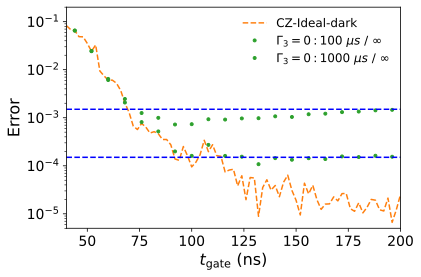

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(params[:,0], 10**params[:,2], '-', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_9, '+', color=colors[4], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(param_44[:,0], 10**f_3000_50, 'D', color=colors[5], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.plot(para_dark[:,0], 10**para_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
# plt.plot(para[:,0], 10**f_dark_1600_9, 'x', color=colors[2], label=r'ZL:$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(para[:,0], 10**f_dark2_1600_9, 'D', color=colors[2], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
plt.plot(para[:,0], 10**f_dark_100_0_oplist, '.', color=colors[2], label=r'$\Gamma_3=0:100\ \mu s\ /\ \infty$')
# plt.plot(para[:,0], 10**f_dark_100_0_gamma23, '.', color=colors[2], label=r'$\Gamma_3=10\Gamma_2:100\ \mu s\ /\ \infty$')
plt.plot(para[:,0], 10**f_dark_1000_0_oplist, '.', color=colors[2], label=r'$\Gamma_3=0:1000\ \mu s\ /\ \infty$')
# plt.plot(para[:,0], 10**f_dark_1000_0_gamma23, 'x', color=colors[2], label=r'$\Gamma_3=10\Gamma_2:1000\ \mu s\ /\ \infty$')
# plt.plot(para[:,0], 10**f_dark_1000_0_100gamma23, '+', color=colors[2], label=r'$\Gamma_3=100\Gamma_2:1000\ \mu s\ /\ \infty$')
# plt.plot(para[:,0], 10**f_dark_0_10_oplist, '+', color=colors[2], label=r'JC-lst:$\infty\ /\ 10\ \mu s$')
# plt.plot(para[:,0], 10**f_dark_0_100_oplist, '*', color=colors[2], label=r'JC-lst:$\infty\ /\ 100\ \mu s$')
# plt.plot(para[:,0], 10**f_dark_3000_50, '*', color=colors[3], label=r'$3000\ \mu s\ /\ 50\ \mu s$ - dark')
tg = 200
g = 0.75
plt.axhline(y= g*tg/1000e3, color='b', linestyle='--')
plt.axhline(y= g*tg/100e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


In [13]:
f_0_10_r0 = np.array([ # ratio = 0
-1.077453019382125, -1.3023297050739404, -1.9386429390089854, -2.099539254215521 ,
-2.274225254291767, -2.307016353632379, -2.371651082262373, -2.22083056747898 ,
-2.4285954683429636, -2.405766363042772, -2.1234530559994496, -2.038930018591436 ,
-1.9920063539195916, -2.3453019953551313, -1.9951230934635003, -1.9479360531463579 ,
-1.9199803590919562, -1.9041817191969181, -1.89871104147584, -1.886463818238399 ,
])

f_0_100_r0 = np.array([
-1.08335186409443, -1.3151509578661753, -2.016939944440978, -2.2611051339128823 ,
-2.950458102076347, -3.042451306719301, -3.1840099852728536, -3.080151672698599 ,
-3.300382470400138, -3.289820581227957, -3.0782242651492444, -3.011298560180331 ,
-2.9681827138855454, -3.306730518859775, -2.9887675002549416, -2.9375735247277825 ,
-2.909669313871294, -2.8961302433059792, -2.8913014944794644, -2.8797183510838495 ,
])

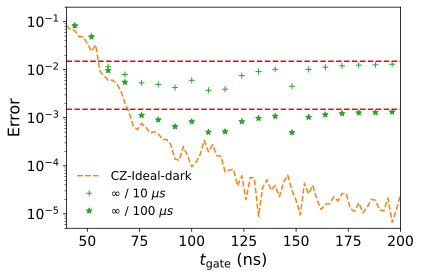

In [22]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(para_dark[:,0], 10**para_dark[:,2], '--', color=colors[1], label=r'CZ-Ideal-dark')
plt.plot(para[:,0], 10**f_0_10_r0, '+', color=colors[2], label=r'$\infty\ /\ 10\ \mu s$')
plt.plot(para[:,0], 10**f_0_100_r0, '*', color=colors[2], label=r'$\infty\ /\ 100\ \mu s$')

tg = 200
g = 0.75
plt.axhline(y=g * tg/100e3, color='r', linestyle='--')
plt.axhline(y=g * tg/10e3, color='r', linestyle='--')
# g = 1.5
# plt.axhline(y=g * tg/100e3, color='b', linestyle='--')
# plt.axhline(y=g * tg/10e3, color='b', linestyle='--')
plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')


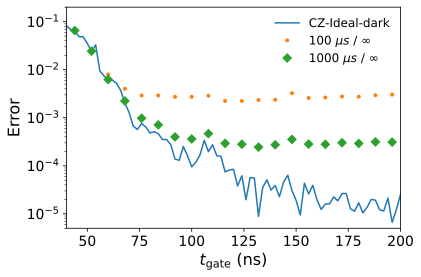

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
# plt.plot(params[:,0], 10**params[:,2], '--', color=colors[0], label=r'CZ-Ideal')
# plt.plot(param_44[:,0], 10**f_1600_9, '+', color=colors[4], label=r'$1600\ \mu s\ /\ 9\ \mu s$')
# plt.plot(param_44[:,0], 10**f_3000_50, 'D', color=colors[5], label=r'$3000\ \mu s\ /\ 50\mu s$')

plt.plot(para_dark[:,0], 10**para_dark[:,2], color=colors[0], label=r'CZ-Ideal-dark')

plt.plot(para[:,0], 10**f_dark_100_0_gamma23, '.', color=colors[1], label=r'$100\ \mu s\ /\ \infty$')
plt.plot(para[:,0], 10**f_dark_1000_0_gamma23, 'D', color=colors[2], label=r'$1000\ \mu s\ /\ \infty$')

plt.yscale('log')
plt.xlabel(r'$t_{\rm gate}$ (ns)')
plt.ylabel('Error')
# plt.grid()
plt.xlim(40,200)
plt.ylim(5e-6,2e-1)
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.)  # 0.5 makes the legend 50% transparent
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig('../image/cz_error-vs-tg_dark.pdf', dpi=300, bbox_inches='tight')
